In [1]:
# Reload the data

import pandas as pd

df = pd.read_csv("../data/features/features_core_v2.csv")
df["timestamp_hour"] = pd.to_datetime(df["timestamp_hour"])

target_columns = [c for c in df.columns if c.startswith("target_aqi_")]
print("Loaded:", df.shape)

Loaded: (78204, 145)


In [2]:
# Rebuild the finalized feature list. IDs/timestamps and every future target are excluded; station_name stays and is encoded inside the pipeline.

unsafe_cols = list(target_columns)
unsafe_cols += ["location_id", "provider_name", "timestamp_hour"]

final_feature_columns = [c for c in df.columns if c not in unsafe_cols and c not in target_columns]
categorical_check = df[final_feature_columns].select_dtypes(include=["object", "category"]).columns.tolist()
assert categorical_check == ["station_name"], f"Review unexpected categorical predictors: {categorical_check}"
print("Final feature count:", len(final_feature_columns))
print("Categorical predictors encoded in-pipeline:", categorical_check)

Final feature count: 118
Categorical predictors encoded in-pipeline: ['station_name']


In [3]:
# Rebuild the chronological split boundaries

unique_timestamps = sorted(df["timestamp_hour"].unique())
n = len(unique_timestamps)

train_end_idx = int(n * 0.70)
val_end_idx = int(n * 0.85)

train_end = unique_timestamps[train_end_idx]
val_end = unique_timestamps[val_end_idx]

print("Train end:", train_end)
print("Val end:  ", val_end)

Train end: 2026-06-11 13:00:00
Val end:   2026-06-26 22:00:00


In [4]:
# Rebuild purged splits. Keep every row with a valid horizon target.
# The persistence comparison later uses the current-AQI-available subset only.

def purged_split_for_horizon(df, horizon_hours, train_end, val_end):
    target_col = f"target_aqi_{horizon_hours}h"
    label_time = df["timestamp_hour"] + pd.Timedelta(hours=horizon_hours)
    
    is_train = (df["timestamp_hour"] < train_end) & (label_time < train_end)
    is_val = (
        (df["timestamp_hour"] >= train_end) & (df["timestamp_hour"] < val_end) &
        (label_time >= train_end) & (label_time < val_end)
    )
    is_test = (
        (df["timestamp_hour"] >= val_end) &
        (label_time >= val_end)
    )
    
    train_df = df[is_train].dropna(subset=[target_col])
    val_df = df[is_val].dropna(subset=[target_col])
    test_df = df[is_test].dropna(subset=[target_col])
    
    return train_df, val_df, test_df

splits_by_horizon = {}
for h in range(1, 25):
    train_df_h, val_df_h, test_df_h = purged_split_for_horizon(df, h, train_end, val_end)
    splits_by_horizon[h] = {"train": train_df_h, "val": val_df_h, "test": test_df_h}

print("Rebuilt splits for all 24 horizons.")

Rebuilt splits for all 24 horizons.


In [5]:
# Configure CatBoost. It receives station_name directly as a native categorical feature.

from catboost import CatBoostRegressor

categorical_cols = df[final_feature_columns].select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in final_feature_columns if c not in categorical_cols]
pipeline_input_cols = numeric_cols + categorical_cols

catboost_params = dict(loss_function="MAE", eval_metric="MAE", iterations=1000, learning_rate=0.05, depth=8, l2_leaf_reg=5.0, random_seed=42, od_type="Iter", od_wait=75, verbose=False, allow_writing_files=False)
print("CatBoost configured. Input columns:", len(pipeline_input_cols))

CatBoost configured. Input columns: 118


In [6]:
# Load your saved persistence baseline

persistence_df = pd.read_csv("../reports/persistence_baseline_metrics.csv")
print(persistence_df)

    horizon        mae  n_rows_evaluated
0         1   2.322516              9953
1         2   4.313096              9850
2         3   6.145639              9757
3         4   7.822307              9674
4         5   9.366934              9593
5         6  10.833018              9522
6         7  12.180982              9454
7         8  13.439876              9389
8         9  14.620161              9325
9        10  15.757775              9260
10       11  16.867493              9192
11       12  17.976104              9123
12       13  19.053899              9054
13       14  20.109146              8988
14       15  21.135111              8926
15       16  22.140891              8865
16       17  23.120005              8808
17       18  24.061728              8748
18       19  24.943045              8691
19       20  25.780584              8632
20       21  26.579923              8577
21       22  27.337675              8523
22       23  28.036823              8473
23       24  28.

In [7]:
# Train all 24 models, evaluate on test, and save each one

import joblib
from sklearn.metrics import mean_absolute_error

trained_models = {}
test_predictions_all = []
metrics_by_horizon = []

for h in range(1, 25):
    target_col = f"target_aqi_{h}h"
    
    train_df = splits_by_horizon[h]["train"]
    val_df = splits_by_horizon[h]["val"]
    test_df = splits_by_horizon[h]["test"]
    
    X_train = train_df[pipeline_input_cols]
    y_train = train_df[target_col]
    
    X_val = val_df[pipeline_input_cols]
    y_val = val_df[target_col]

    X_test = test_df[pipeline_input_cols]
    y_test = test_df[target_col]
    
    # A fresh model per horizon; validation MAE controls early stopping, never test MAE.
    this_model = CatBoostRegressor(**catboost_params)
    this_model.fit(X_train, y_train, cat_features=categorical_cols, eval_set=(X_val, y_val), use_best_model=True)
    
    y_pred_test = this_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred_test)
    
    # Persistence exists only when current AQI exists; use this matched subset for a fair comparison.
    matched_test = test_df.dropna(subset=["current_aqi"])
    matched_model_mae = mean_absolute_error(matched_test[target_col], this_model.predict(matched_test[pipeline_input_cols]))
    
    trained_models[h] = this_model
    
    metrics_by_horizon.append({
        "horizon": h,
        "mae": mae,
        "mae_matched_to_persistence": matched_model_mae,
        "n_train": len(train_df),
        "n_test": len(test_df)
    })
    
    # Store predictions row-by-row for later analysis
    horizon_predictions = test_df[["station_name", "timestamp_hour"]].copy()
    horizon_predictions["horizon"] = h
    horizon_predictions["predicted_aqi"] = y_pred_test
    horizon_predictions["observed_aqi"] = y_test.values
    test_predictions_all.append(horizon_predictions)
    
    # Save this horizon's trained model to disk
    joblib.dump(this_model, f"../models/horizon_{h:02d}h.joblib")
    
    print(f"Horizon {h:>2}h -> MAE: {mae:.3f}  (train: {len(train_df)}, test: {len(test_df)})")

metrics_df = pd.DataFrame(metrics_by_horizon)
test_predictions_df = pd.concat(test_predictions_all, ignore_index=True)

Horizon  1h -> MAE: 2.645  (train: 42203, test: 10032)
Horizon  2h -> MAE: 4.366  (train: 42203, test: 9998)
Horizon  3h -> MAE: 6.037  (train: 42203, test: 9964)
Horizon  4h -> MAE: 7.420  (train: 42203, test: 9930)
Horizon  5h -> MAE: 8.729  (train: 42203, test: 9895)
Horizon  6h -> MAE: 9.931  (train: 42203, test: 9860)
Horizon  7h -> MAE: 10.848  (train: 42203, test: 9825)
Horizon  8h -> MAE: 11.783  (train: 42203, test: 9789)
Horizon  9h -> MAE: 12.437  (train: 42203, test: 9753)
Horizon 10h -> MAE: 13.582  (train: 42203, test: 9717)
Horizon 11h -> MAE: 14.491  (train: 42203, test: 9681)
Horizon 12h -> MAE: 15.158  (train: 42203, test: 9645)
Horizon 13h -> MAE: 16.107  (train: 42203, test: 9609)
Horizon 14h -> MAE: 17.454  (train: 42203, test: 9573)
Horizon 15h -> MAE: 18.559  (train: 42203, test: 9537)
Horizon 16h -> MAE: 19.712  (train: 42203, test: 9501)
Horizon 17h -> MAE: 21.893  (train: 42203, test: 9465)
Horizon 18h -> MAE: 22.033  (train: 42193, test: 9429)
Horizon 19h -> 

In [8]:
comparison = metrics_df.merge(persistence_df, on="horizon", suffixes=("_model", "_persistence"))
comparison["improvement"] = comparison["mae_persistence"] - comparison["mae_matched_to_persistence"]
print(comparison[["horizon", "mae_model", "mae_matched_to_persistence", "mae_persistence", "improvement"]])

metrics_df.to_csv("../reports/metrics_by_horizon.csv", index=False)
test_predictions_df.to_csv("../reports/test_predictions.csv", index=False)
print("Saved.")

    horizon  mae_model  mae_matched_to_persistence  mae_persistence  \
0         1   2.645252                    2.565057         2.322516   
1         2   4.365586                    4.244623         4.313096   
2         3   6.036990                    5.904064         6.145639   
3         4   7.420470                    7.275285         7.822307   
4         5   8.729226                    8.567607         9.366934   
5         6   9.931111                    9.764233        10.833018   
6         7  10.848219                   10.655480        12.180982   
7         8  11.782624                   11.610461        13.439876   
8         9  12.436696                   12.244388        14.620161   
9        10  13.582050                   13.371211        15.757775   
10       11  14.491111                   14.337825        16.867493   
11       12  15.158385                   14.974367        17.976104   
12       13  16.107475                   15.949320        19.053899   
13    

In [9]:
# MAE by station

station_mae = (
    test_predictions_df
    .groupby("station_name")[["observed_aqi", "predicted_aqi"]]
    .apply(lambda g: mean_absolute_error(g["observed_aqi"], g["predicted_aqi"]), include_groups=False)
    .reset_index(name="mae")
    .sort_values("mae", ascending=False)
)

print(station_mae)

                                        station_name        mae
4                               Bawana, Delhi - DPCC  26.201389
20                         NSIT Dwarka, Delhi - CPCB  24.334692
21                           Najafgarh, Delhi - DPCC  21.378895
0                               Alipur, Delhi - DPCC  20.601365
10                    Dwarka-Sector 8, Delhi - DPCC   19.725552
36                            Wazirpur, Delhi - DPCC  19.516861
1                      Anand Vihar, New Delhi - DPCC  19.365791
5                   Burari Crossing, New Delhi - IMD  19.229824
22                              Narela, Delhi - DPCC  18.758308
30                              Rohini, Delhi - DPCC  18.523793
26                          Patparganj, Delhi - DPCC  17.946019
9       Dr. Karni Singh Shooting Range, Delhi - DPCC  17.371444
16                       Lodhi Road, New Delhi - IMD  16.597539
31                            Shadipur, Delhi - CPCB  16.038647
33                         Sonia Vihar, 

In [10]:
# Define AQI severity bands

def aqi_to_band(aqi_value):
    if pd.isna(aqi_value):
        return None
    elif aqi_value <= 50:
        return "Good"
    elif aqi_value <= 100:
        return "Satisfactory"
    elif aqi_value <= 200:
        return "Moderate"
    elif aqi_value <= 300:
        return "Poor"
    elif aqi_value <= 400:
        return "Very Poor"
    else:
        return "Severe"

test_predictions_df["severity_band"] = test_predictions_df["observed_aqi"].apply(aqi_to_band)

print(test_predictions_df["severity_band"].value_counts())

severity_band
Moderate        162582
Satisfactory     55469
Poor              9048
Good              3528
Very Poor          384
Name: count, dtype: int64


In [11]:
# MAE by severity band

severity_mae = (
    test_predictions_df
    .groupby("severity_band", observed=True)[["observed_aqi", "predicted_aqi"]]
    .apply(lambda g: mean_absolute_error(g["observed_aqi"], g["predicted_aqi"]), include_groups=False)
    .reset_index(name="mae")
)

# Reorder rows so severity increases top to bottom
band_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
severity_mae["severity_band"] = pd.Categorical(severity_mae["severity_band"], categories=band_order, ordered=True)
severity_mae = severity_mae.sort_values("severity_band")

print(severity_mae)

  severity_band        mae
0          Good  46.880327
3  Satisfactory  21.353379
1      Moderate  12.288060
2          Poor  32.475334
4     Very Poor  84.405561


In [12]:

print(test_predictions_df["severity_band"].value_counts())

train_band_counts = df.copy()
train_band_counts["severity_band"] = train_band_counts["current_aqi"].apply(aqi_to_band)
print(train_band_counts["severity_band"].value_counts())

severity_band
Moderate        162582
Satisfactory     55469
Poor              9048
Good              3528
Very Poor          384
Name: count, dtype: int64
severity_band
Moderate        41141
Poor             9918
Satisfactory     7225
Very Poor        2184
Good              186
Severe            174
Name: count, dtype: int64


In [13]:
# Save results

station_mae.to_csv("../reports/mae_by_station.csv", index=False)
severity_mae.to_csv("../reports/mae_by_severity_band.csv", index=False)
print("Saved station and severity breakdowns.")

Saved station and severity breakdowns.


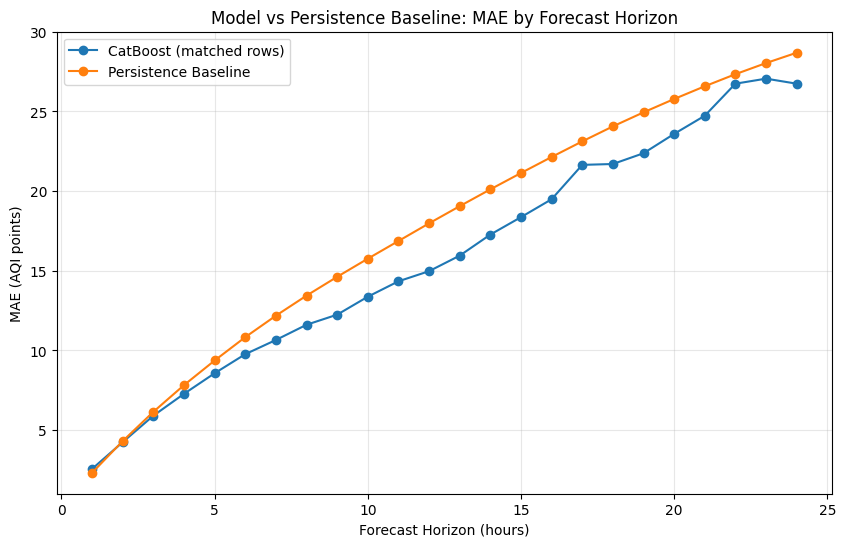

In [14]:
# Plot 1: MAE vs. forecast horizon

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(comparison["horizon"], comparison["mae_matched_to_persistence"], marker="o", label="CatBoost (matched rows)")
ax.plot(comparison["horizon"], comparison["mae_persistence"], marker="o", label="Persistence Baseline")

ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("MAE (AQI points)")
ax.set_title("Model vs Persistence Baseline: MAE by Forecast Horizon")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig("../reports/plots/mae_vs_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

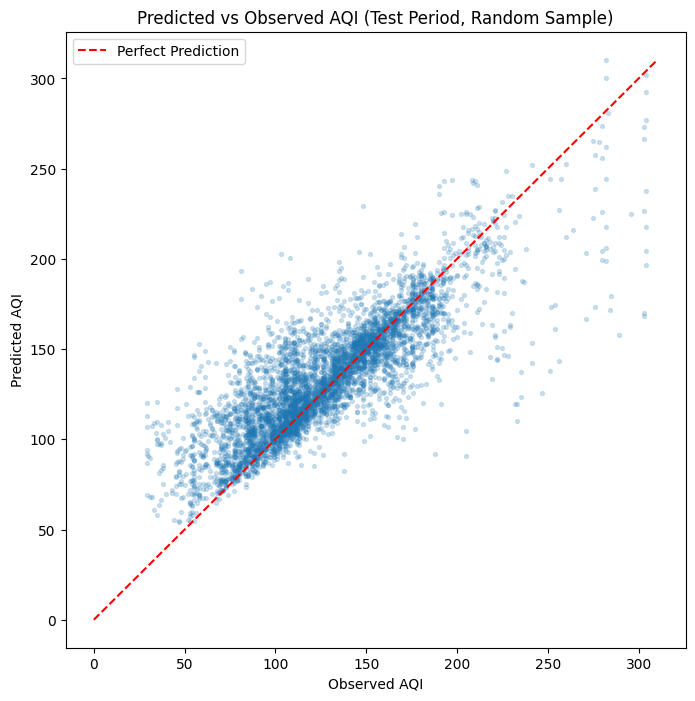

In [15]:
# Plot 2: Predicted vs. observed AQI

fig, ax = plt.subplots(figsize=(8, 8))

sample = test_predictions_df.sample(n=5000, random_state=42)

ax.scatter(sample["observed_aqi"], sample["predicted_aqi"], alpha=0.2, s=8)

max_val = max(sample["observed_aqi"].max(), sample["predicted_aqi"].max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Prediction")

ax.set_xlabel("Observed AQI")
ax.set_ylabel("Predicted AQI")
ax.set_title("Predicted vs Observed AQI (Test Period, Random Sample)")
ax.legend()

plt.savefig("../reports/plots/predicted_vs_observed.png", dpi=150, bbox_inches="tight")
plt.show()

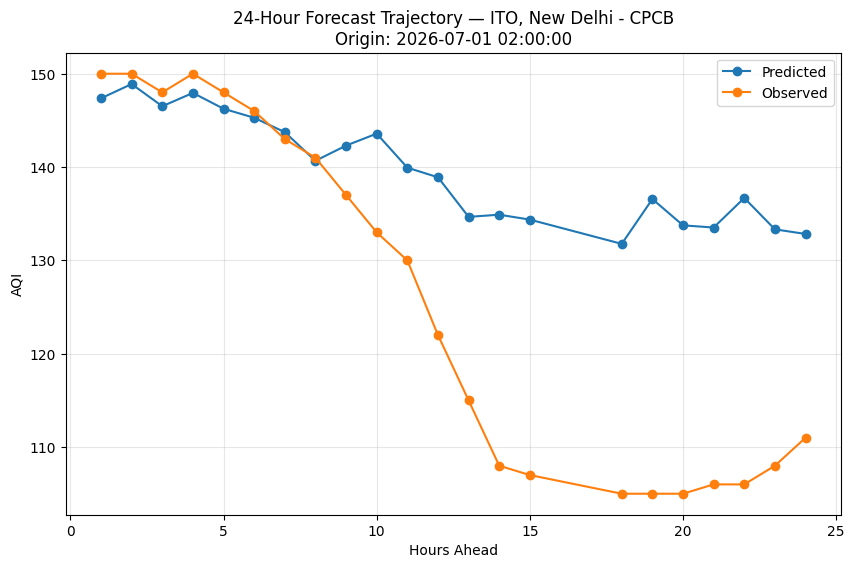

In [16]:
# Plot 3: One 24-hour trajectory vs. actual, for a specific station

chosen_station = "ITO, New Delhi - CPCB"

station_data = test_predictions_df[test_predictions_df["station_name"] == chosen_station]

# Pick one forecast origin timestamp that has predictions across many horizons
origin_time = station_data["timestamp_hour"].iloc[100]
trajectory = station_data[station_data["timestamp_hour"] == origin_time].sort_values("horizon")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(trajectory["horizon"], trajectory["predicted_aqi"], marker="o", label="Predicted")
ax.plot(trajectory["horizon"], trajectory["observed_aqi"], marker="o", label="Observed")

ax.set_xlabel("Hours Ahead")
ax.set_ylabel("AQI")
ax.set_title(f"24-Hour Forecast Trajectory — {chosen_station}\nOrigin: {origin_time}")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig("../reports/plots/trajectory_example.png", dpi=150, bbox_inches="tight")
plt.show()

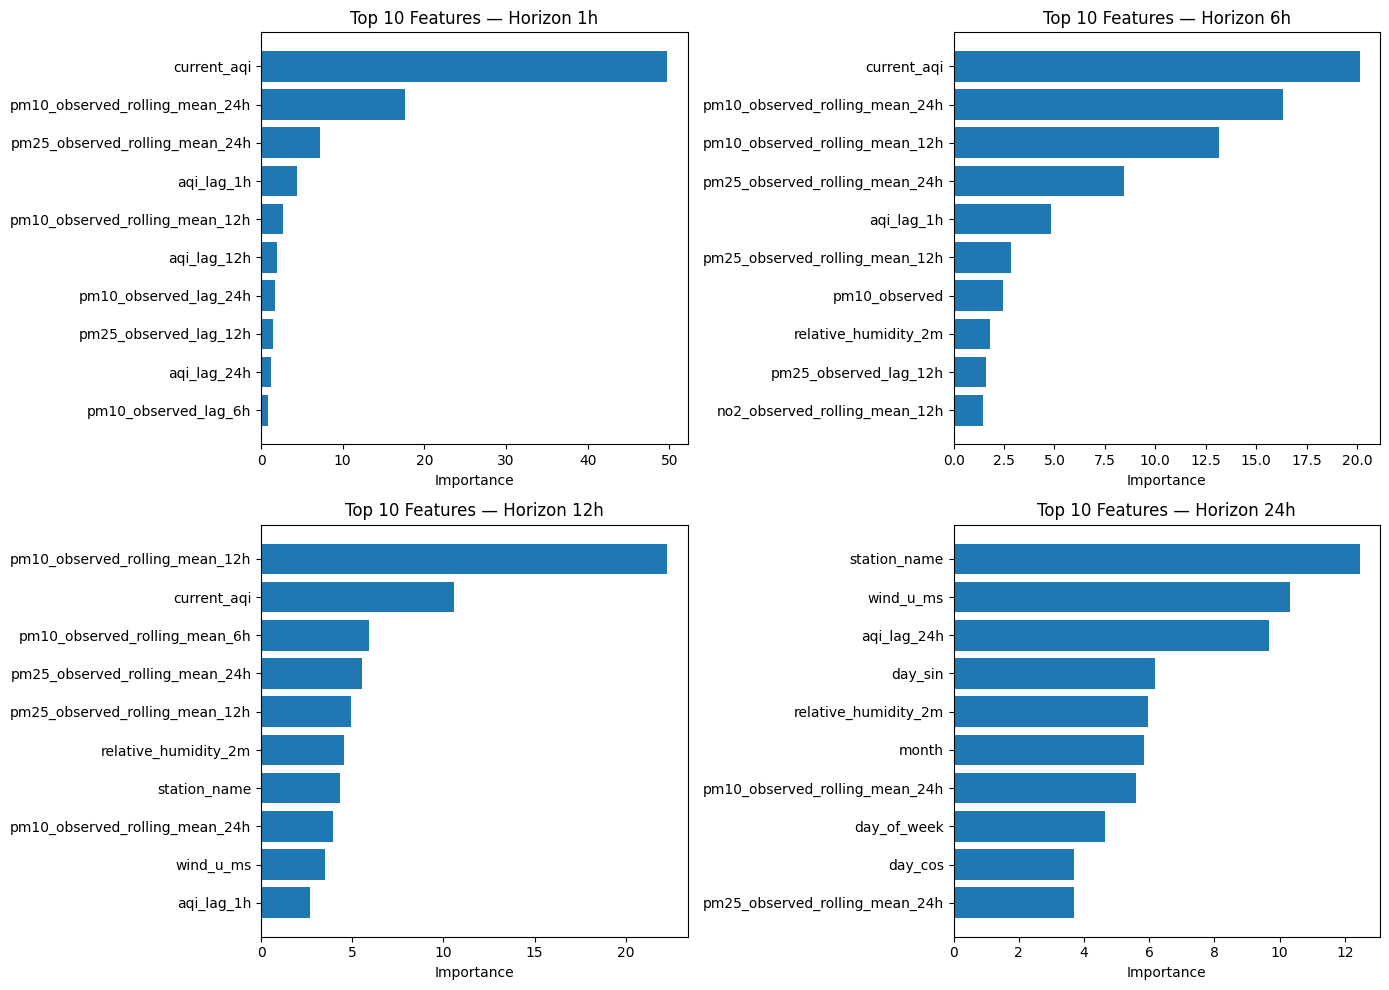

In [17]:
# Plot 4: Feature importance at representative horizons

import numpy as np

horizons_to_check = [1, 6, 12, 24]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, h in enumerate(horizons_to_check):
    model = trained_models[h]
    
    # CatBoost supplies native prediction-value-change importances.
    importances = model.get_feature_importance()
    
    top_n = 10
    top_indices = np.argsort(importances)[-top_n:]
    top_features = [pipeline_input_cols[j] for j in top_indices]
    top_values = importances[top_indices]
    
    axes[i].barh(top_features, top_values)
    axes[i].set_title(f"Top {top_n} Features — Horizon {h}h")
    axes[i].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("../reports/plots/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

metrics_df["rmse"] = metrics_df["horizon"].apply(lambda h: 
    np.sqrt(mean_squared_error(
        splits_by_horizon[h]["test"][f"target_aqi_{h}h"].dropna(),
        trained_models[h].predict(splits_by_horizon[h]["test"].dropna(subset=[f"target_aqi_{h}h"])[pipeline_input_cols])
    ))
)
print(metrics_df[["horizon", "mae", "rmse"]])

    horizon        mae       rmse
0         1   2.645252   4.868372
1         2   4.365586   7.310727
2         3   6.036990   9.510626
3         4   7.420470  11.340458
4         5   8.729226  12.958560
5         6   9.931111  14.498753
6         7  10.848219  15.417139
7         8  11.782624  16.672804
8         9  12.436696  17.424579
9        10  13.582050  18.814126
10       11  14.491111  19.930256
11       12  15.158385  20.720016
12       13  16.107475  21.967969
13       14  17.454130  23.452690
14       15  18.559477  24.712779
15       16  19.711602  26.000439
16       17  21.893044  28.261001
17       18  22.032983  28.511323
18       19  22.627967  29.283934
19       20  23.813148  30.749922
20       21  25.006285  32.259422
21       22  27.062430  34.131470
22       23  27.387352  34.945835
23       24  27.139181  34.932266


In [19]:
# Save RMSE alongside everything else

final_comparison = metrics_df.merge(persistence_df, on="horizon", suffixes=("_model", "_persistence"))
final_comparison["mae_improvement"] = final_comparison["mae_persistence"] - final_comparison["mae_matched_to_persistence"]
final_comparison["mean_mae_all_horizons"] = final_comparison["mae_model"].mean()

final_comparison.to_csv("../reports/final_metrics_comparison.csv", index=False)

print("Mean MAE across all 24 horizons:", final_comparison["mae_model"].mean().round(3))
print("Mean MAE across all 24 horizons (persistence):", final_comparison["mae_persistence"].mean().round(3))
print(final_comparison[["horizon", "mae_model", "rmse", "mae_persistence", "mae_improvement", "mae_matched_to_persistence"]])

Mean MAE across all 24 horizons: 16.093
Mean MAE across all 24 horizons (persistence): 17.61
    horizon  mae_model       rmse  mae_persistence  mae_improvement  \
0         1   2.645252   4.868372         2.322516        -0.242541   
1         2   4.365586   7.310727         4.313096         0.068473   
2         3   6.036990   9.510626         6.145639         0.241575   
3         4   7.420470  11.340458         7.822307         0.547022   
4         5   8.729226  12.958560         9.366934         0.799328   
5         6   9.931111  14.498753        10.833018         1.068786   
6         7  10.848219  15.417139        12.180982         1.525502   
7         8  11.782624  16.672804        13.439876         1.829415   
8         9  12.436696  17.424579        14.620161         2.375773   
9        10  13.582050  18.814126        15.757775         2.386565   
10       11  14.491111  19.930256        16.867493         2.529669   
11       12  15.158385  20.720016        17.976104     

In [22]:
# Final deliverables checklist

import os
required_deliverables = {
    "24 trained models": len([f for f in os.listdir("../models") if f.endswith(".joblib")]) == 24,
    "feature_list.txt": os.path.exists("../reports/feature_list.txt"),
    "split_boundaries.json": os.path.exists("../reports/split_boundaries.json"),
    "metrics_by_horizon.csv": os.path.exists("../reports/metrics_by_horizon.csv"),
    "test_predictions.csv": os.path.exists("../reports/test_predictions.csv"),
    "persistence_baseline_metrics.csv": os.path.exists("../reports/persistence_baseline_metrics.csv"),
    "mae_by_station.csv": os.path.exists("../reports/mae_by_station.csv"),
    "mae_by_severity_band.csv": os.path.exists("../reports/mae_by_severity_band.csv"),
    "4 required plots": all(os.path.exists(f"../reports/plots/{p}") for p in 
        ["mae_vs_horizon.png", "predicted_vs_observed.png", "trajectory_example.png", "feature_importance.png"])
}

for item, done in required_deliverables.items():
    print(f"{'YES' if done else 'NO'} {item}")

YES 24 trained models
YES feature_list.txt
YES split_boundaries.json
YES metrics_by_horizon.csv
YES test_predictions.csv
YES persistence_baseline_metrics.csv
YES mae_by_station.csv
YES mae_by_severity_band.csv
YES 4 required plots
